# Climate pilot — figures

Section 4.10. Same six models, same protocol, different content domain (fabricated solar-vs-wind
investment) and chart type (line chart). 25 posts, so 25 trials per cell against the main study's
100 — the summaries are solid, per-cell numbers are noisier.

**Which files these read.** `outputs/` holds the **value-labelled** chart re-run; the original
unlabelled run is kept at `outputs/pre_label_backup/`. Section 4.10 quotes both, so the last cell
puts them side by side rather than picking one.

This is the dataset where two of the three write-up errors in this project happened — Gemma-E4B
called "uninformative", Gemma-12B called "a position bias" — both from conditioning on one variable
instead of crossing two. That cross-tab is the first figure below.

In [1]:
import sys, subprocess
from pathlib import Path

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1").is_dir())
print(subprocess.run(["git", "-C", str(REPO_ROOT), "pull"],
                     capture_output=True, text=True).stdout)

for m in [k for k in list(sys.modules) if k.startswith(("e1_utils", "e1_figures"))]:
    del sys.modules[m]

sys.path.insert(0, str(REPO_ROOT / "experiments/e1"))
sys.path.insert(0, str(REPO_ROOT / "statistical_analysis"))

from e1_figures import (ROSTER, plot_competence_vs_collapse, plot_position_diagnostic,
                        competence_collapse_series, position_diagnostic_series)

FIG_DIR = REPO_ROOT / "statistical_analysis" / "outputs"
print(f"root: {REPO_ROOT}")


Already up to date.

root: /home/jovyan/conformity-llms-facebook-posts


## 1. What is each model tracking?

Off-diagonal trials only. A tall blue bar means the answer moves with where the **correct** post
sits; a tall red bar means it moves with where the **more-engaged** post sits. Reading only one of
these is what produced both corrections.

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/climate_position_diagnostic_metrics.png


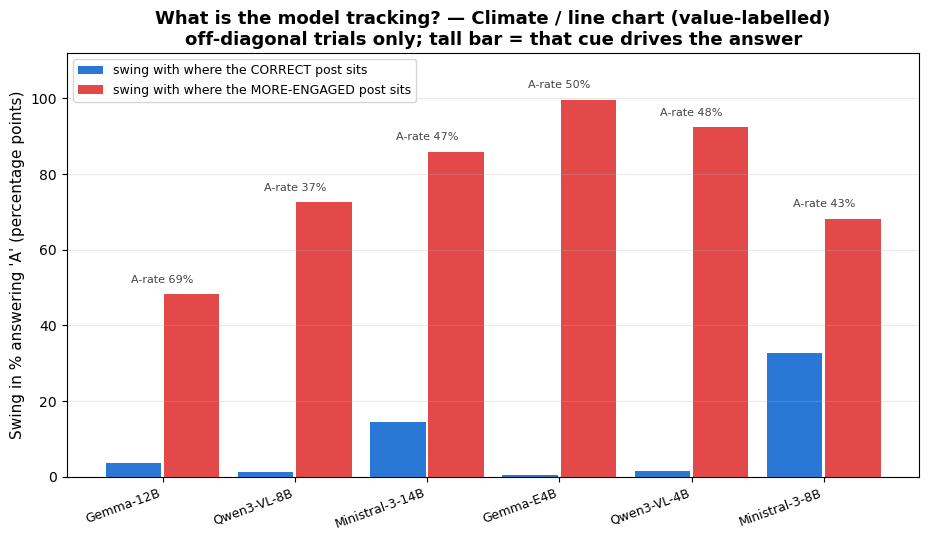

In [2]:
plot_position_diagnostic(REPO_ROOT, "e1_results_metrics_paired.json",
                         "Climate / line chart (value-labelled)",
                         experiment_dir="experiments/e1_climate",
                         save_path=FIG_DIR / "climate_position_diagnostic_metrics.png")

## 2. Competence vs. collapse

Hollow, red-flagged dots are models whose tied-engagement score is a positional artifact rather
than competence — for those, the left-hand number measures nothing.

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/climate_competence_collapse_metrics.png


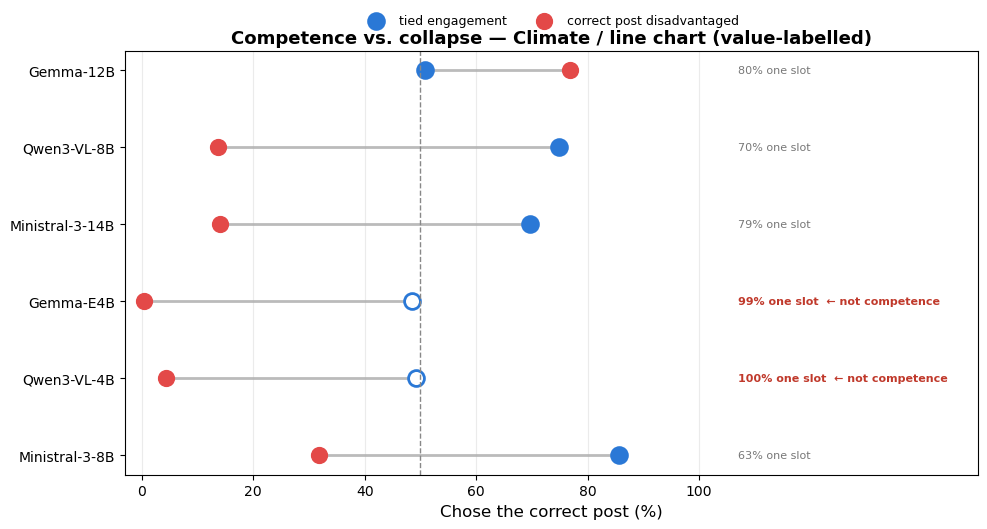

⚠ Gemma-E4B: tied-engagement 48.6% is NOT competence — it answers one slot on 99.4% of 175 tied trials.
⚠ Qwen3-VL-4B: tied-engagement 49.1% is NOT competence — it answers one slot on 100.0% of 175 tied trials.


In [3]:
plot_competence_vs_collapse(REPO_ROOT, "e1_results_metrics_paired.json",
                            "Climate / line chart (value-labelled)",
                            experiment_dir="experiments/e1_climate",
                            save_path=FIG_DIR / "climate_competence_collapse_metrics.png")

## 3. Labelled vs. unlabelled chart, and climate vs. main study

The robustness check from Section 4.10, as numbers. Printing the chart's values did **not** improve
paired-comparison competence and for Ministral-3-14B measurably lowered it (92.0% → 69.7%) — flagged
in the thesis as unexplained.

In [4]:
def summary(fname, experiment_dir, models=None, label=""):
    c = competence_collapse_series(REPO_ROOT, fname, models, experiment_dir)
    p = {d["label"]: d for d in position_diagnostic_series(REPO_ROOT, fname, models, experiment_dir)}
    print(f"\n{label or experiment_dir}")
    print(f"{'model':17s} {'diagonal':>9s} {'pressure':>9s} {'tiedA':>7s} {'swCorr':>8s} {'swEng':>7s}")
    print("-" * 62)
    for d in c:
        q = p[d["label"]]
        flag = "  ← tied score is positional" if max(d["tied_a_rate"], 100-d["tied_a_rate"]) >= 80 else ""
        print(f"{d['label']:17s} {d['diagonal']:8.1f}% {d['pressure']:8.1f}% "
              f"{d['tied_a_rate']:6.1f}% {q['swing_correct']:7.1f}p {q['swing_engagement']:6.1f}p{flag}")

summary("e1_results_metrics_paired.json", "experiments/e1_climate", label="CLIMATE — value-labelled chart")
summary("e1_results_metrics_paired.json", "experiments/e1", label="MAIN STUDY — pie chart")



CLIMATE — value-labelled chart
model              diagonal  pressure   tiedA   swCorr   swEng
--------------------------------------------------------------
Gemma-12B             50.9%     76.8%   79.8%     3.5p   48.2p
Qwen3-VL-8B           74.9%     13.7%   29.7%     1.3p   72.6p
Ministral-3-14B       69.7%     14.1%   79.4%    14.4p   85.9p
Gemma-E4B             48.6%      0.4%   99.4%     0.4p   99.6p  ← tied score is positional
Qwen3-VL-4B           49.1%      4.4%  100.0%     1.3p   92.4p  ← tied score is positional
Ministral-3-8B        85.7%     31.8%   63.4%    32.6p   68.2p

MAIN STUDY — pie chart
model              diagonal  pressure   tiedA   swCorr   swEng
--------------------------------------------------------------
Gemma-12B             82.7%     84.7%   41.0%    75.6p    5.6p
Qwen3-VL-8B           55.0%      1.4%    8.4%     3.5p   93.5p  ← tied score is positional
Ministral-3-14B       51.7%      0.0%  100.0%     0.4p   99.6p  ← tied score is positional
Gemma-E4B    

In [5]:
# the unlabelled originals, kept alongside rather than overwritten
import json
print(f"{'model':17s} {'labelled':>9s} {'unlabelled':>11s}")
print("-" * 40)
for label, slug in ROSTER:
    row = []
    for sub in ("", "pre_label_backup"):
        p = REPO_ROOT / "experiments/e1_climate" / slug / "outputs" / sub / "e1_results_metrics_paired.json"
        if not p.exists():
            row.append(None); continue
        d = [r for r in json.loads(p.read_text()) if r["answer"] in ("A", "B")]
        t = [r for r in d if r["correct_scale"] == r["incorrect_scale"]]
        row.append(sum(1 for r in t if r["liked_variant"] == "correct") / len(t) * 100)
    a, b = row
    print(f"{label:17s} {a:8.1f}% " + (f"{b:10.1f}%" if b is not None else "          —"))


model              labelled  unlabelled
----------------------------------------
Gemma-12B             50.9%           —
Qwen3-VL-8B           74.9%       80.0%
Ministral-3-14B       69.7%       92.0%
Gemma-E4B             48.6%           —
Qwen3-VL-4B           49.1%           —
Ministral-3-8B        85.7%           —
